In [1]:
import numpy as np
import pandas as pd

import scarf

# Keep routine progress messages out of the teaching output.
scarf.configure_output(level="WARNING", progress=False)

# Download the prepared example, including its saved analysis.
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)

Downloading bucket files: 52931410 / 52931410 complete

Downloading bytes: 52931410 / 52931410 complete

In [2]:
# Open the datastore for the following analysis.
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
# Reuse the saved run and its frozen cell selection.
analysis_run = ds.pipeline.open(label="docs_default")
# Keep the graph used by the saved analysis.
graph = analysis_run["connectivity_map"]
# Use the complete feature universe for this assay.
all_features = analysis_run["feature_universe"]
# Inspect the opened assays and their dimensions.
ds

DataStore has 3696 (3696) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'G2M_score', 'RNA_UMAP1', 
            'RNA_UMAP2', 'RNA_clusters', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo', 'S_score', 'clusters', 'clusters_coarse'
   RNA assay has 27998 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'highly_variable_genes', 
            'nCells'

In [3]:
# Read the published cell-type labels for the selected cells.
annotations = ds.cells.fetch("clusters", key="I")
# Mark ductal cells as the source population.
source = annotations == "Ductal"
# Mark the pooled terminal populations.
sink = np.isin(annotations, ["Alpha", "Beta", "Delta"])
# Require at least one annotated source cell and one sink cell.
if not source.any() or not sink.any():
    raise ValueError("Source and sink annotations must both be present")
# Start every graph cell with zero source or sink mass.
source_sink_vector = np.zeros(len(annotations), dtype=float)
# Share total mass -1 among the source cells.
source_sink_vector[source] = -1.0 / source.sum()
# Share total mass +1 among the pooled sink cells.
source_sink_vector[sink] = 1.0 / sink.sum()
# Orient the graph using the chosen source and sinks.
pseudotime_ref = ds.run_pseudotime_scoring(graph, ss_vec=source_sink_vector)
# Check how many cells anchor the two ends of the ordering.
pd.Series({"source cells": int(source.sum()), "sink cells": int(sink.sum())})

source cells     916
sink cells      1142
dtype: int64

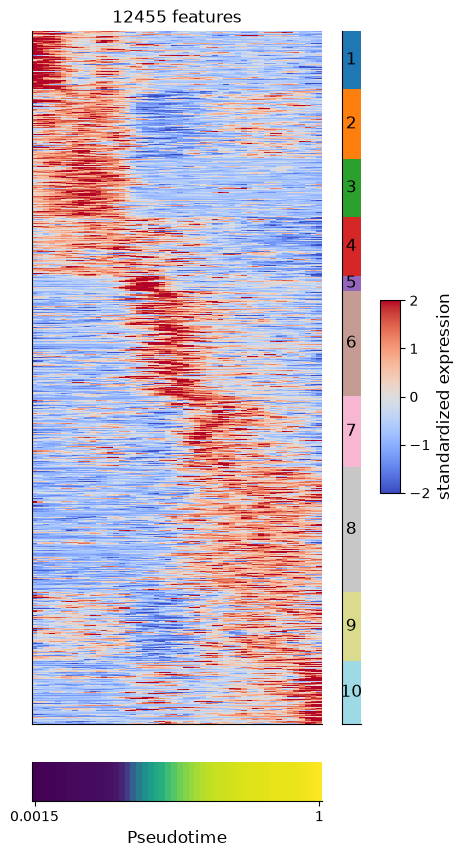

In [4]:
# Group genes with similar expression profiles along pseudotime.
modules_ref = ds.run_pseudotime_aggregation(pseudotime_ref, features=all_features)
# Display the ordered expression profiles and their modules.
ds.plots.pseudotime_heatmap(aggregation=modules_ref)

In [5]:
# Load the saved gene-module assignments.
modules = ds.load_pseudotime_aggregation(modules_ref)
# Pair each retained gene with its module label.
module_genes = pd.DataFrame({
    "gene": modules.feature_names,
    "module": modules.feature_clusters,
})
# Count the genes assigned to each expression module.
module_genes.groupby("module").size().rename("genes")

module
1     1049
2     1251
3     1048
4     1054
5      270
6     1886
7     1285
8     2242
9     1240
10    1130
Name: genes, dtype: int64

In [6]:
# Choose the first module to demonstrate gene lookup.
module_id = module_genes["module"].min()
# Inspect the first twenty genes in the chosen module.
module_genes.loc[module_genes["module"] == module_id, "gene"].head(20)

17              Mcm3
26             Prim2
52              Uxs1
65            Stk17b
70             Hspd1
71              Tyw5
75              Orc2
77             Trak2
93             Bard1
125         Serpine2
133              Ncl
139            Hjurp
152             Pask
156            Dtymk
177            Ddx18
183           Zranb3
184             Mcm6
208             Ipo9
214    2310009B15Rik
230             Dhx9
Name: gene, dtype: str